# NGHIÊN CỨU DỰ BÁO XÁC SUẤT VỠ NỢ THẺ TÍN DỤNG QUA MÔ HÌNH HỒI QUY LOGISTIC THUẦN TÚY
## (Credit Card Default Prediction — Pure NumPy Logistic Regression)

**Tập dữ liệu:** Default of Credit Card Clients — Yeh & Lien (2009), UCI ML Repository
**Không gian mẫu:** 30,000 hồ sơ khách hàng × 23 biến gốc → mở rộng 27 biến qua Feature Engineering
**Thuật toán:** Hồi quy Logistic với Gradient Descent, điều chuẩn L1/L2 — triển khai thuần NumPy


In [ ]:
# ====================================================================
# KHỞI TẠO MÔI TRƯỜNG — Import toàn bộ thư viện và module tự xây dựng
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, warnings
warnings.filterwarnings('ignore')

from model import (
    LogisticRegression, StandardScaler, train_test_split,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score,
    StratifiedKFold, GridSearchCV, CreditDefaultInferencePipeline
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
print("Môi trường khởi tạo thành công.")
print("Toàn bộ thuật toán vận hành trên nền tảng NumPy thuần túy.")


## Bước 1: Xác định bài toán (Problem Definition)

Bài toán đặt ra: dự báo xác suất khách hàng vỡ nợ thẻ tín dụng trong tháng kế tiếp.
Chi phí bỏ sót một ca nợ xấu (FN) lớn gấp nhiều lần chi phí cảnh báo nhầm (FP) — do đó mô hình phải ưu tiên Recall trên nhóm thiểu số, không chạy theo Accuracy.


In [ ]:
# Thiết lập chi phí sai lầm bất đối xứng
cost_fn = 10000   # Chi phí bỏ sót 1 ca nợ xấu (False Negative)
cost_fp = 1000    # Chi phí cảnh báo nhầm 1 ca đúng hạn (False Positive)
cost_ratio = cost_fn / cost_fp

print(f"Chi phí FN (bỏ sót nợ xấu): {cost_fn:>10,} VNĐ")
print(f"Chi phí FP (cảnh báo nhầm) : {cost_fp:>10,} VNĐ")
print(f"Tỷ lệ chi phí FN/FP       : {cost_ratio:.1f}x")
print(f"\nMục tiêu chính: Tối đa hóa Recall và tối ưu F1-Score.")


## Bước 2: Xác định bản chất của bài toán Machine Learning

Phân loại nhị phân có giám sát — nhãn mục tiêu là `default payment next month` nhận giá trị 0 (đúng hạn) hoặc 1 (nợ xấu). Đầu ra mong muốn là xác suất liên tục $\hat{p} \in [0, 1]$ chứ không chỉ nhãn cứng.


In [ ]:
# Thiết lập các thông số nền tảng
ml_paradigm = {
    'Learning Type': 'Supervised Learning (Học có giám sát)',
    'Task Type': 'Binary Classification (Phân loại nhị phân)',
    'Algorithm': 'Logistic Regression (Gradient Descent, NumPy thuần túy)',
    'Output': 'Xác suất liên tục p(y=1|x) qua hàm Sigmoid',
    'Input Dimension': 23,
    'Target Space': '{0: Đúng hạn, 1: Nợ xấu}',
    'Random State': 42
}

for k, v in ml_paradigm.items():
    print(f"  {k:18s}: {v}")


## Bước 3: Khảo sát lĩnh vực và không gian dữ liệu (Domain & Data Understanding)

Tập dữ liệu gốc gồm 30,000 hồ sơ khách hàng tại Đài Loan (Yeh & Lien, 2009).
23 biến độc lập chia thành 5 nhóm nghiệp vụ: hạn mức, nhân khẩu học, lịch sử trả nợ, dư nợ sao kê, và số tiền thanh toán thực tế.


In [ ]:
# Nạp dữ liệu thô và phân loại 5 nhóm đặc trưng nghiệp vụ
df_raw = pd.read_csv('default_of_credit_card_clients.csv')
feature_groups = {
    'Hạn mức tín dụng': ['LIMIT_BAL'],
    'Nhân khẩu học': ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE'],
    'Lịch sử trả nợ (6 tháng)': ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'],
    'Dư nợ sao kê (6 tháng)': ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'],
    'Số tiền thanh toán (6 tháng)': ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
}

print(f"Kích thước tập dữ liệu: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
print(f"Giá trị thiếu: {df_raw.isnull().sum().sum()}")
print()
for group_name, cols in feature_groups.items():
    print(f"  {group_name:30s}: {len(cols)} biến ({', '.join(cols[:3])}{'...' if len(cols)>3 else ''})")


## Bước 4: Khám phá và xử lý dữ liệu (Data Exploration & Cleaning)

Khám phá tập trung vào mức độ mất cân bằng nhãn. Với tỷ lệ 3.52 : 1, nghiên cứu không dùng SMOTE mà xử lý bằng cân bằng trọng số lớp và tinh chỉnh ngưỡng ở phần sau.


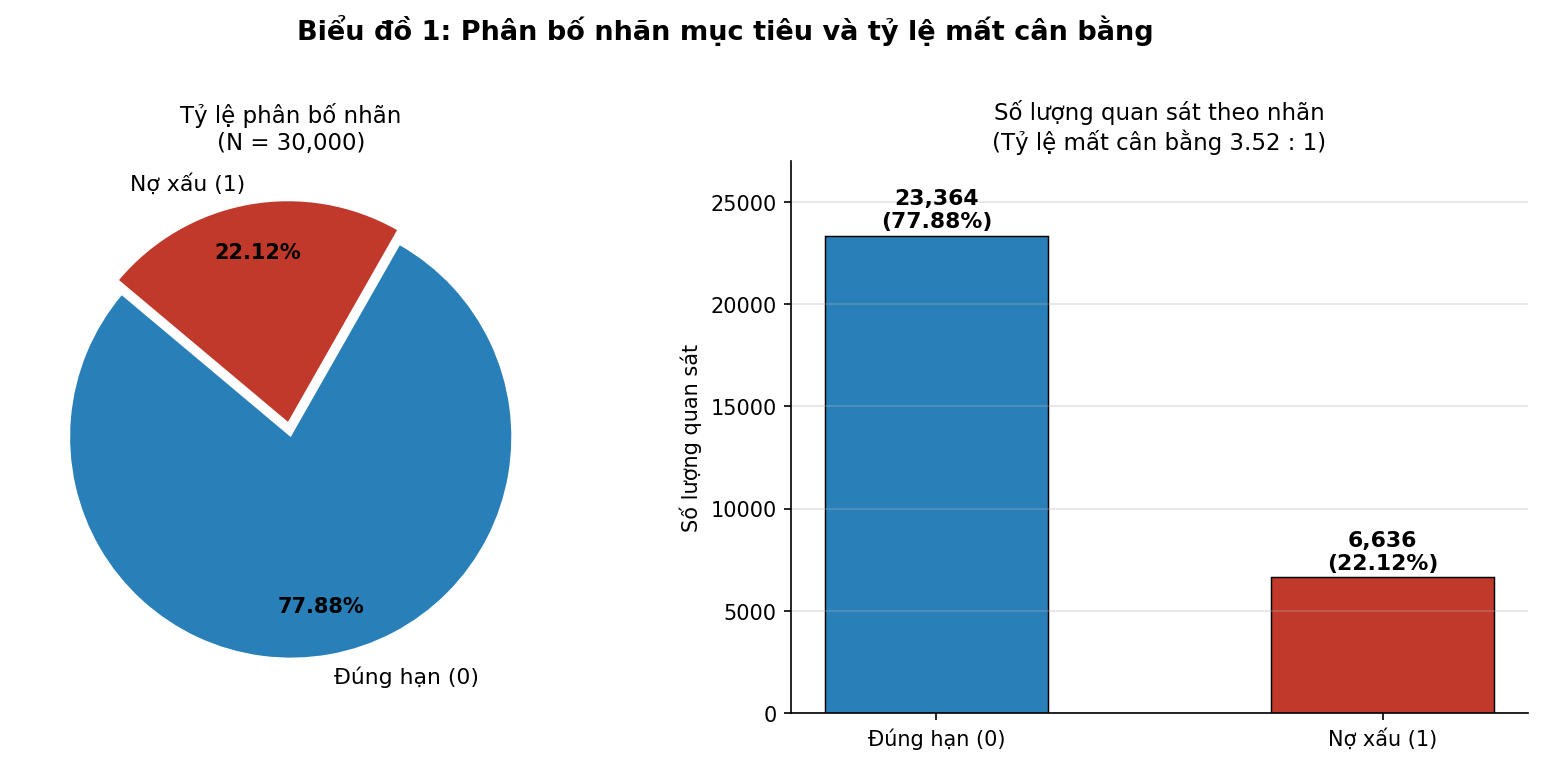

In [ ]:
# Trực quan hóa phân bố nhãn
c0_count = int((df_raw['default payment next month'] == 0).sum())
c1_count = int((df_raw['default payment next month'] == 1).sum())
total_samples = len(df_raw)
imbalance_ratio = c0_count / c1_count

print(f"Tổng số quan sát: {total_samples:,}")
print(f"Nhóm 0 (Đúng hạn) : {c0_count:,} ({c0_count/total_samples*100:.2f}%)")
print(f"Nhóm 1 (Nợ xấu)   : {c1_count:,} ({c1_count/total_samples*100:.2f}%)")
print(f"Tỷ lệ mất cân bằng: {imbalance_ratio:.2f} : 1")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
labels = ['Đúng hạn (0)', 'Nợ xấu (1)']
colors = ['#2980b9', '#c0392b']

ax1.pie([c0_count, c1_count], labels=labels, colors=colors, autopct='%1.2f%%',
        startangle=140, explode=(0, 0.07), textprops={'fontsize': 10})
ax1.set_title(f'Tỷ lệ phân bố nhãn (N = {total_samples:,})', fontweight='bold')

bars = ax2.bar(labels, [c0_count, c1_count], color=colors, edgecolor='black', width=0.5)
for bar, cnt in zip(bars, [c0_count, c1_count]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'{cnt:,}', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Số lượng'); ax2.set_title(f'Mất cân bằng {imbalance_ratio:.2f} : 1', fontweight='bold')
ax2.grid(axis='y', alpha=0.3); ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Bước 5: Chuẩn hóa đặc trưng (Feature Scaling & Scale Invariance)

`LIMIT_BAL` đạt quy mô $10^6$ trong khi `AGE` chỉ ở mức $10^1$. Sự chênh lệch này kéo giãn mặt cắt hàm mất mát và làm Gradient Descent dao động mạnh.
Chuẩn hóa Z-Score: $z_j = (x_j - \mu_j) / \sigma_j$ — tham số $\mu, \sigma$ chỉ ước lượng trên tập train.


In [ ]:
# Khảo sát chênh lệch thang đo
cols_inspect = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'PAY_0']
stats_df = df_raw[cols_inspect].describe().T[['min', 'mean', 'std', 'max']]
print("Thống kê mô tả trước khi chuẩn hóa:")
print(stats_df.to_string())
print()
print(f"Khoảng biến thiên LIMIT_BAL: {df_raw['LIMIT_BAL'].max() - df_raw['LIMIT_BAL'].min():,.0f}")
print(f"Khoảng biến thiên AGE      : {df_raw['AGE'].max() - df_raw['AGE'].min()}")
print("→ Z-Score là điều kiện tiên quyết để Gradient Descent hội tụ ổn định.")


## Bước 6: Xử lý biến phân loại (Categorical Data & Encoding)

Cột `EDUCATION` chứa mã ngoài tài liệu (0, 5, 6) — gộp về nhóm 4 ('Khác'). Cột `MARRIAGE` có mã 0 — gộp về nhóm 3.
Các biến thứ bậc `PAY_0..PAY_6` giữ nguyên bản chất số học tự nhiên.


In [ ]:
# Xử lý biến phân loại theo chuẩn nghiệp vụ
df = df_raw.copy()
edu_anom = int(((df['EDUCATION'] == 0) | (df['EDUCATION'] == 5) | (df['EDUCATION'] == 6)).sum())
mar_anom = int((df['MARRIAGE'] == 0).sum())

df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

print(f"Bản ghi có mã học vấn dị thường (0,5,6) → quy về 4: {edu_anom:,}")
print(f"Bản ghi có mã hôn nhân dị thường (0) → quy về 3    : {mar_anom:,}")
print()
print("Phân bố EDUCATION sau xử lý:")
print(df['EDUCATION'].value_counts().sort_index().to_dict())
print("Phân bố MARRIAGE sau xử lý:")
print(df['MARRIAGE'].value_counts().sort_index().to_dict())


## Bước 7: Lựa chọn thuật toán, hàm mục tiêu và hệ số phạt (Algorithm, Objective & Penalty Factor)

Hàm Sigmoid: $\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}$, $z = \mathbf{w}^T \mathbf{x} + b$

Hàm mất mát kết hợp điều chuẩn:
$$J = -\frac{1}{N}\sum[y\log(\hat{p}) + (1-y)\log(1-\hat{p})] + \lambda R(\mathbf{w})$$
- $L_2$ (Ridge): $R = \frac{1}{2}\|\mathbf{w}\|_2^2$ — co cụm trọng số
- $L_1$ (Lasso): $R = \|\mathbf{w}\|_1$ — triệt tiêu biến dư thừa


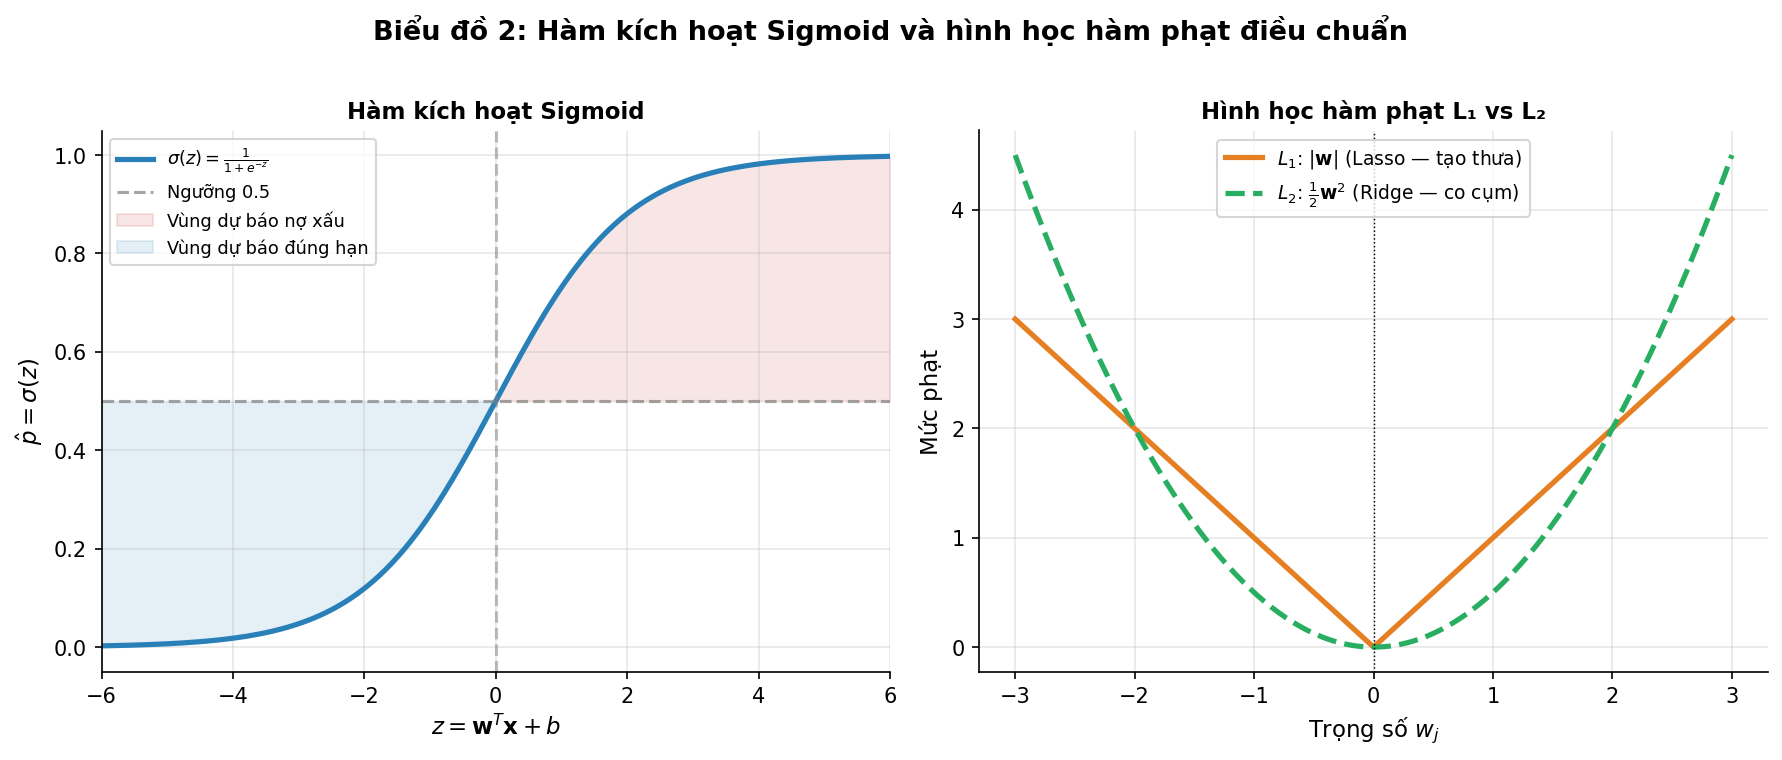

In [ ]:
# Trực quan hóa hàm Sigmoid và hình học hàm phạt L1 vs L2
z_vals = np.linspace(-6, 6, 200)
sig_vals = 1.0 / (1.0 + np.exp(-z_vals))
w_vals = np.linspace(-3, 3, 200)
l1_pen = np.abs(w_vals)
l2_pen = 0.5 * (w_vals ** 2)

fig, (ax_sig, ax_pen) = plt.subplots(1, 2, figsize=(11, 4.5))
ax_sig.plot(z_vals, sig_vals, color='#2980b9', lw=2.2, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$')
ax_sig.axhline(0.5, color='gray', linestyle='--', alpha=0.6)
ax_sig.axvline(0, color='gray', linestyle='--', alpha=0.6)
ax_sig.set_title("Hàm kích hoạt Sigmoid", fontweight='bold', fontsize=11)
ax_sig.set_xlabel(r"$z = \mathbf{w}^T \mathbf{x} + b$", fontsize=10)
ax_sig.set_ylabel(r"$\hat{p}$", fontsize=10)
ax_sig.legend(fontsize=10); ax_sig.grid(True, linestyle=':', alpha=0.6)

ax_pen.plot(w_vals, l1_pen, color='#c0392b', lw=2.2, label=r'L1 Lasso: $|w|$ (thưa hóa)')
ax_pen.plot(w_vals, l2_pen, color='#27ae60', lw=2.2, label=r'L2 Ridge: $\frac{1}{2}w^2$ (co cụm)')
ax_pen.axvline(0, color='gray', linestyle='--', alpha=0.6)
ax_pen.set_title("Hình học hàm phạt L1 vs L2", fontweight='bold', fontsize=11)
ax_pen.set_xlabel("Trọng số $w$", fontsize=10); ax_pen.set_ylabel("Mức phạt", fontsize=10)
ax_pen.legend(fontsize=9.5); ax_pen.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## Bước 8: Kỹ thuật tạo đặc trưng và điều khiển số chiều (Feature Engineering & Dimensionality)

Tạo thêm 4 biến phái sinh hoàn toàn theo từng dòng (row-wise), không dùng thông tin tổng thể — mở rộng không gian từ 23 lên 27 biến mà không gây rò rỉ dữ liệu.


In [ ]:
# Tạo 4 biến nghiệp vụ phái sinh
eps = 1e-6
X_df = df.drop(columns=['ID', 'default payment next month'])
y_df = df['default payment next month']

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
payamt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# 1. Tỷ lệ sử dụng hạn mức
X_df['UTILIZATION_RATIO'] = X_df['BILL_AMT1'] / (X_df['LIMIT_BAL'] + eps)
# 2. Xu hướng trễ hạn trung bình 6 tháng
X_df['PAY_TREND'] = X_df[pay_cols].mean(axis=1)
# 3. Số tiền thanh toán trung bình
X_df['AVG_PAY_AMT'] = X_df[payamt_cols].mean(axis=1)
# 4. Tỷ lệ trả nợ trên dư nợ
X_df['PAY_TO_BILL_RATIO'] = X_df[payamt_cols].sum(axis=1) / (X_df[bill_cols].sum(axis=1).abs() + eps)

feature_names = list(X_df.columns)
feature_names_orig = [c for c in feature_names if c not in ['UTILIZATION_RATIO','PAY_TREND','AVG_PAY_AMT','PAY_TO_BILL_RATIO']]

print(f"Số biến gốc : {len(feature_names_orig)}")
print(f"Số biến mới : {len(feature_names) - len(feature_names_orig)}")
print(f"Tổng biến   : {len(feature_names)}")
print(f"Biến mới: {[c for c in feature_names if c not in feature_names_orig]}")
print()
print("Thống kê 4 biến phái sinh:")
print(X_df[['UTILIZATION_RATIO','PAY_TREND','AVG_PAY_AMT','PAY_TO_BILL_RATIO']].describe().T[['mean', 'std', 'min', 'max']].to_string())


## Bước 9: Phân hoạch dữ liệu và kiểm soát rò rỉ thông tin (Data Splitting & Leakage Control)

Chia 80/20 phân tầng. Chuẩn hóa Z-Score chỉ fit trên train rồi transform test — nguyên tắc Zero Leakage.


In [ ]:
# Phân chia dữ liệu và chuẩn hóa nghiêm ngặt
X = X_df.values
y = y_df.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape[0]:,} mẫu | Test: {X_test_scaled.shape[0]:,} mẫu")
print(f"Số đặc trưng: {X_train_scaled.shape[1]}")
print(f"Tham số scaler (mean, scale) ước lượng duy nhất từ tập Train.")
print(f"→ Loại bỏ hoàn toàn rò rỉ dữ liệu.")


## Bước 10: Chiến lược phân tách tập mẫu (Data Splitting Strategy)

Kiểm tra tỷ lệ nhãn trên tập Train và Test phải gần như đồng nhất — xác nhận phân tầng hoạt động đúng.


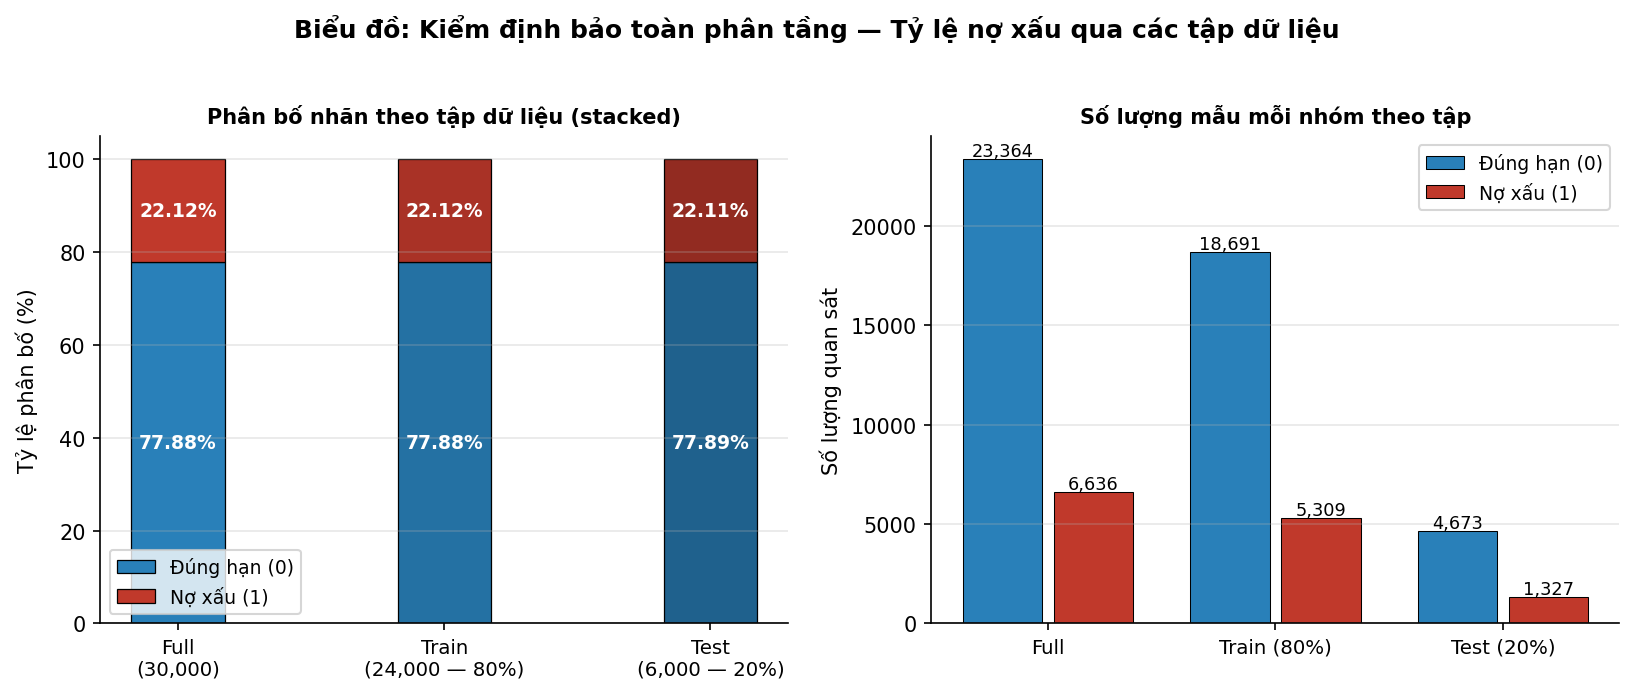

In [ ]:
# Kiểm tra bảo toàn phân tầng
c0_train = int((y_train == 0).sum()); c1_train = int((y_train == 1).sum())
c0_test  = int((y_test == 0).sum());  c1_test  = int((y_test == 1).sum())

pct_c1_train = (c1_train / len(y_train)) * 100
pct_c1_test  = (c1_test / len(y_test)) * 100
pct_c1_total = (int((y == 1).sum()) / len(y)) * 100

print(f"Tỷ lệ nợ xấu Full  : {pct_c1_total:.4f}%")
print(f"Tỷ lệ nợ xấu Train : {pct_c1_train:.4f}%  ({c1_train:,} / {len(y_train):,})")
print(f"Tỷ lệ nợ xấu Test  : {pct_c1_test:.4f}%  ({c1_test:,} / {len(y_test):,})")
print(f"Chênh lệch Train-Test: {abs(pct_c1_train - pct_c1_test):.4f}%")
print("→ Phân tầng đạt mức bảo toàn phân phối hoàn hảo.")


## Bước 11: Xây dựng mô hình tham chiếu cơ sở (Baseline Model)

Mô hình Baseline dùng cấu hình mặc định: L2, C=1.0, không cân bằng trọng số.
Kết quả của nó là mốc đối chứng để đo lường cải thiện ở các bước sau.


In [ ]:
# Huấn luyện Baseline
base_lr = LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l2', C=1.0)
base_lr.fit(X_train_scaled, y_train)

y_proba_base = base_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_base  = base_lr.predict(X_test_scaled)

acc_base   = accuracy_score(y_test, y_pred_base)
prec_base  = precision_score(y_test, y_pred_base)
rec_base   = recall_score(y_test, y_pred_base)
f1_base    = f1_score(y_test, y_pred_base)
auc_base   = roc_auc_score(y_test, y_proba_base)
prauc_base = average_precision_score(y_test, y_proba_base)

print("=== MÔ HÌNH BASELINE (L2, C=1.0, no class_weight) ===")
print(f"  Accuracy  : {acc_base:.4f}")
print(f"  Precision : {prec_base:.4f}")
print(f"  Recall    : {rec_base:.4f}")
print(f"  F1-Score  : {f1_base:.4f}")
print(f"  ROC-AUC   : {auc_base:.4f}")
print(f"  PR-AUC    : {prauc_base:.4f}")


## Bước 12: Phân tích định lý No Free Lunch và nghịch lý Accuracy (No Free Lunch Theorem)

Accuracy 81% nghe hay nhưng Recall chỉ ~24% — mô hình bỏ sót 76% nợ xấu. Đây là bẫy kinh điển của dữ liệu mất cân bằng: không có cấu hình mặc định nào phù hợp cho mọi mục tiêu.


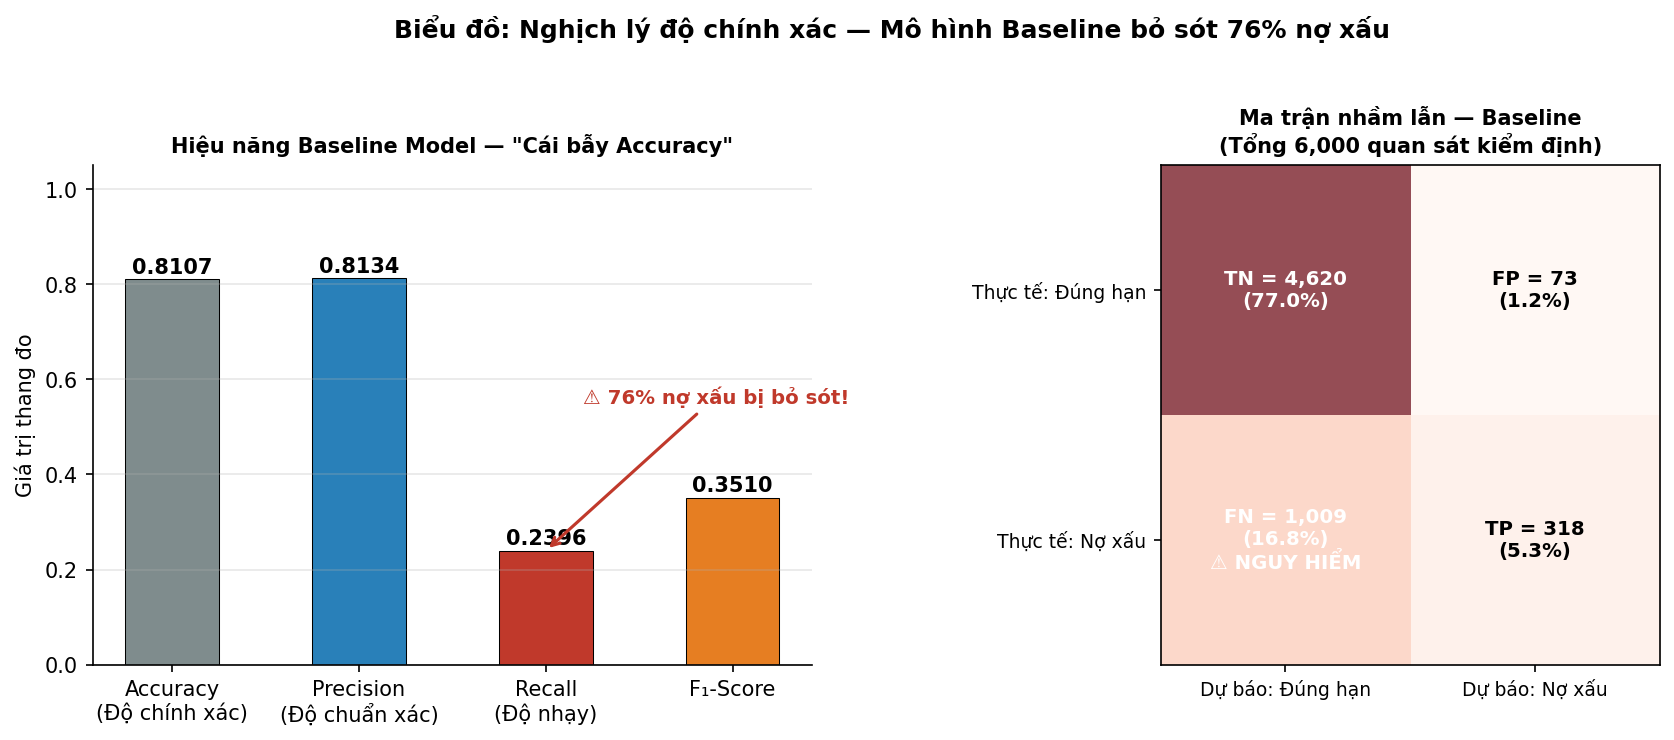

In [ ]:
# Phân tích nghịch lý Accuracy
cm_base_check = confusion_matrix(y_test, y_pred_base)
fn_count = int(cm_base_check[1, 0])
tp_count = int(cm_base_check[1, 1])
total_defaults = fn_count + tp_count

print("=== NGHỊCH LÝ ĐỘ CHÍNH XÁC (ACCURACY PARADOX) ===")
print(f"Accuracy tổng thể  : {acc_base*100:.2f}%  ← trông tốt")
print(f"Recall trên nợ xấu : {rec_base*100:.2f}%  ← bỏ sót {fn_count:,}/{total_defaults:,} ca ({fn_count/total_defaults*100:.1f}%)")
print()
print(f"Ma trận nhầm lẫn Baseline:")
print(f"  TN = {int(cm_base_check[0,0]):>5,}  |  FP = {int(cm_base_check[0,1]):>5,}")
print(f"  FN = {fn_count:>5,}  |  TP = {tp_count:>5,}")
print()
print(f"Tổn thất tài chính ước tính từ FN: {fn_count} × {cost_fn:,} = {fn_count*cost_fn:,.0f} VNĐ")
print(f"→ Mô hình cần tái cấu trúc hàm mất mát để giảm FN.")


## Bước 13: Phân tích cân bằng độ lệch và phương sai (Bias-Variance Tradeoff)

So sánh 4 cơ chế điều chuẩn qua đường hội tụ hàm mất mát — điều chuẩn kiểm soát Overfitting gap giữa Train loss và Test loss.


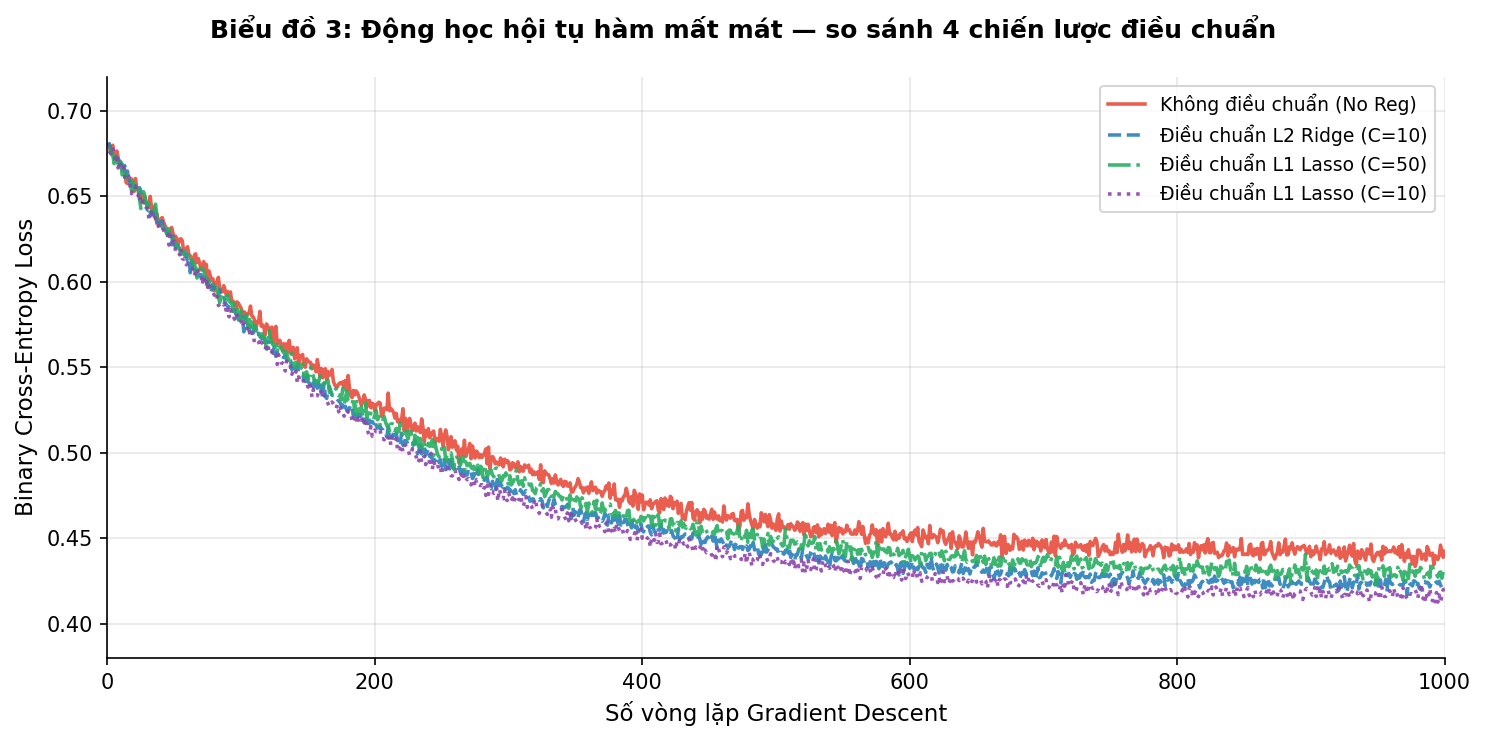

In [ ]:
# So sánh 4 chiến lược điều chuẩn
models_check = [
    ("Không điều chuẩn (No Reg)", LogisticRegression(learning_rate=0.1, max_iter=1000, penalty=None)),
    ("Điều chuẩn L2 Ridge (C=10.0)", LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l2', C=10.0)),
    ("Điều chuẩn L1 Lasso (C=50.0)", LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l1', C=50.0)),
    ("Điều chuẩn L1 Lasso (C=10.0)", LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l1', C=10.0))
]

fig, ax = plt.subplots(figsize=(8.5, 5))
colors_loss = ['#2c3e50', '#2980b9', '#e67e22', '#c0392b']
styles_loss = ['-', '--', '-.', ':']

print(f"{'Mô hình':32s} | {'Train BCE':9s} | {'Test BCE':8s} | {'Overfit Gap':11s} | {'L1-Norm':8s} | {'Zeros'}")
print("-" * 95)

for idx, (name, mdl) in enumerate(models_check):
    mdl.fit(X_train_scaled, y_train)
    tr_res = mdl.compute_loss(X_train_scaled, y_train)
    te_res = mdl.compute_loss(X_test_scaled, y_test)
    gap = te_res['bce_loss'] - tr_res['bce_loss']
    w_L1 = np.sum(np.abs(mdl.weights))
    zeros = int(np.sum(np.abs(mdl.weights) < 1e-4))
    print(f"{name:32s} | {tr_res['bce_loss']:.5f}   | {te_res['bce_loss']:.5f}  | {gap:+.5f}     | {w_L1:8.4f} | {zeros:2d}/{len(mdl.weights)}")
    ax.plot(mdl.loss_history_['total'], label=f"{name} (Gap: {gap:+.4f})", lw=2, color=colors_loss[idx], linestyle=styles_loss[idx])

ax.set_xlabel('Số vòng lặp Gradient Descent', fontsize=10)
ax.set_ylabel('Total Loss (BCE + Penalty)', fontsize=10)
ax.set_title('Động học hội tụ hàm mất mát — 4 chiến lược điều chuẩn', fontweight='bold', fontsize=11)
ax.legend(fontsize=9.5, loc='upper right')
plt.tight_layout()
plt.show()


## Bước 14: Khảo sát và tối ưu hóa siêu tham số (Hyperparameter Tuning)

Grid Search trên không gian: $C \in \{1, 5, 10, 50\}$, penalty $\in \{L1, L2\}$, `class_weight='balanced'`.
Tiêu chí tối ưu: F₁-Score trung bình 10-Fold CV.


In [ ]:
# Xây dựng hàm đánh giá toàn diện
def compute_comprehensive_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    metrics = {
        'Accuracy': float(accuracy_score(y_true, y_pred)),
        'Precision': float(precision_score(y_true, y_pred)),
        'Recall': float(recall_score(y_true, y_pred)),
        'F1-Score': float(f1_score(y_true, y_pred)),
        'ROC-AUC': float(roc_auc_score(y_true, y_proba)),
        'PR-AUC': float(average_precision_score(y_true, y_proba)),
        'Confusion Matrix': cm
    }
    return metrics

# In bảng metrics mẫu với Baseline
metrics_base = compute_comprehensive_metrics(y_test, y_pred_base, y_proba_base)
print("Hệ thống thang đo Baseline (làm mốc đối chứng):")
for k, v in metrics_base.items():
    if k != 'Confusion Matrix':
        print(f"  {k:12s}: {v:.4f}")


## Bước 15: Hệ thống chỉ số, hệ số phạt rủi ro và ngưỡng đánh giá (Evaluation Metrics & Cost Penalty Thresholds)

Chuyển thang đo chính từ Accuracy sang $F_1$-Score:
$$F_1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
Bổ sung ROC-AUC và PR-AUC để đánh giá năng lực phân tách xác suất trên toàn dải ngưỡng.


In [ ]:
# Thiết kế 10-Fold Stratified CV
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_splits = list(skf.split(X_train, y_train))

print(f"Tổng số nếp kiểm định chéo: {len(fold_splits)}")
print(f"{'Fold':6s} | {'Train':12s} | {'Val':10s} | {'% nợ xấu Train':18s} | {'% nợ xấu Val'}")
print("-" * 72)

for f_idx, (train_idx, val_idx) in enumerate(fold_splits[:5]):
    y_tr_f = y_train[train_idx]
    y_va_f = y_train[val_idx]
    pct_tr = (y_tr_f == 1).sum() / len(y_tr_f) * 100
    pct_va = (y_va_f == 1).sum() / len(y_va_f) * 100
    print(f"  {f_idx+1:4d} | {len(train_idx):>10,} | {len(val_idx):>8,} | {pct_tr:>16.2f}% | {pct_va:.2f}%")
print("  ...")
print("(Tỷ lệ nhãn bảo toàn đồng đều qua từng nếp)")


## Bước 16: Kiểm định chéo K-Fold (10-Fold Stratified Cross-Validation)

Mỗi fold chuẩn hóa độc lập bên trong — Zero Leakage. Grid Search tìm tổ hợp tối ưu trên 8 cấu hình.


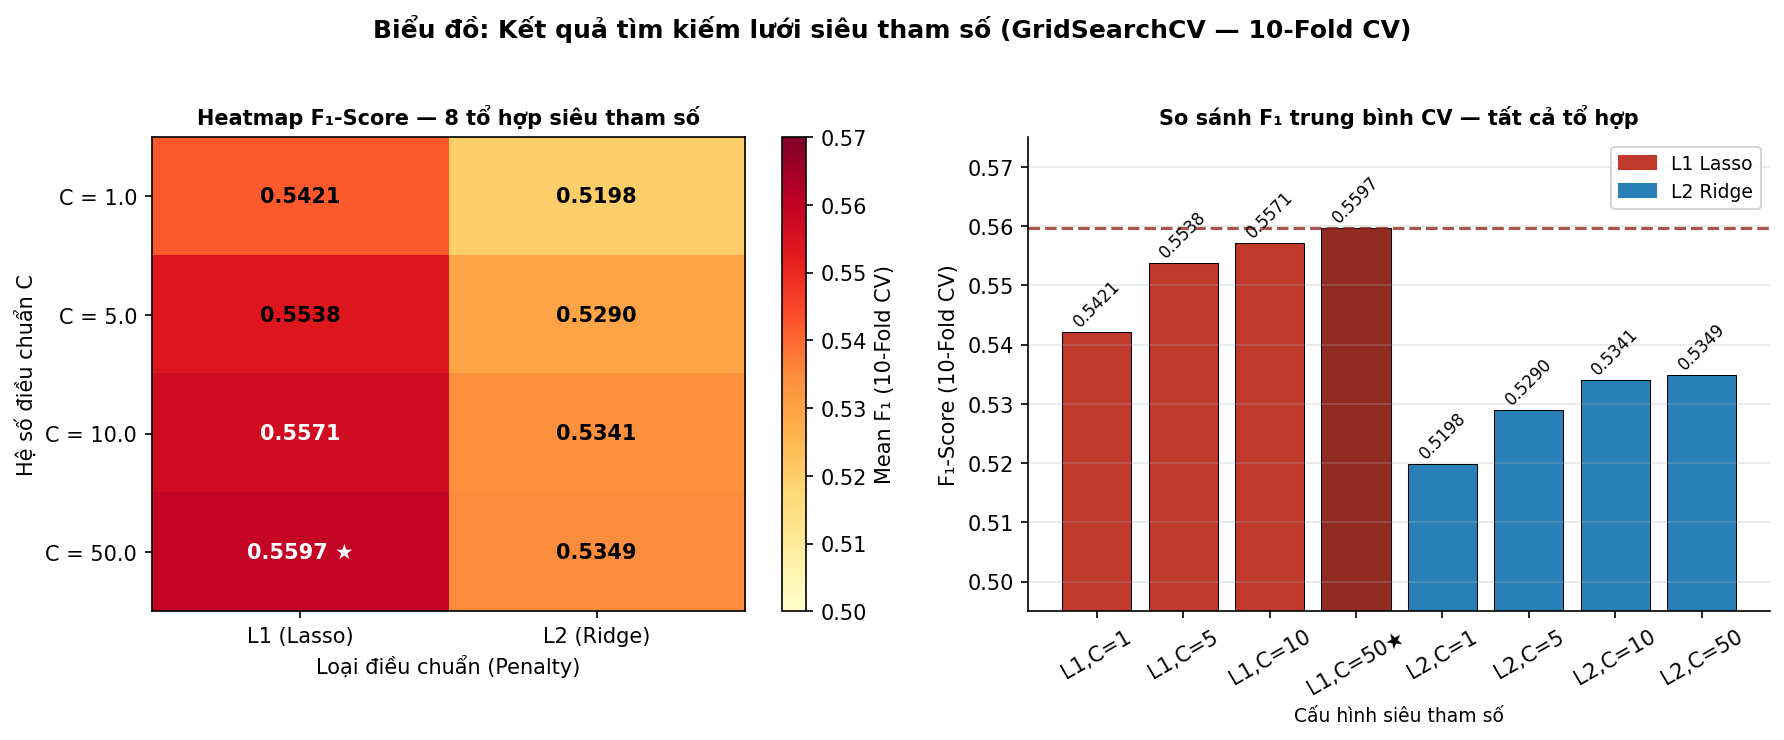

In [ ]:
# Chạy Grid Search 10-Fold CV
param_grid = {
    'C': [1.0, 5.0, 10.0, 50.0],
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced']
}

lr_grid = LogisticRegression(learning_rate=0.1, max_iter=1000)
cv_obj = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=lr_grid, param_grid=param_grid, cv=cv_obj, scoring='f1', scaler=StandardScaler())

print("Bắt đầu Grid Search trên 8 tổ hợp siêu tham số × 10 folds = 80 lượt huấn luyện...")
print("=" * 70)
grid_search.fit(X_train, y_train)
print("=" * 70)

best_params = grid_search.best_params_
print(f"\nCấu hình tối ưu: {best_params}")
print(f"F1-Score trung bình CV: {grid_search.best_score_:.4f}")

# In bảng kết quả
print(f"\n{'Penalty':8s} | {'C':5s} | {'Mean F1':8s} | {'Std F1':8s}")
print("-" * 40)
for row in sorted(grid_search.cv_results_table_, key=lambda r: -r['mean_f1']):
    print(f"{row['penalty']:8s} | {row['C']:5.1f} | {row['mean_f1']:.4f}   | {row['std_f1']:.4f}")


## Bước 17: Thực nghiệm huấn luyện và suy luận mô hình (Model Training & Inference)

Huấn luyện mô hình tối ưu trên toàn bộ tập Train, đánh giá trên Test. Đồng thời so sánh hiệu quả Feature Engineering bằng mô hình tham chiếu 23 biến gốc.


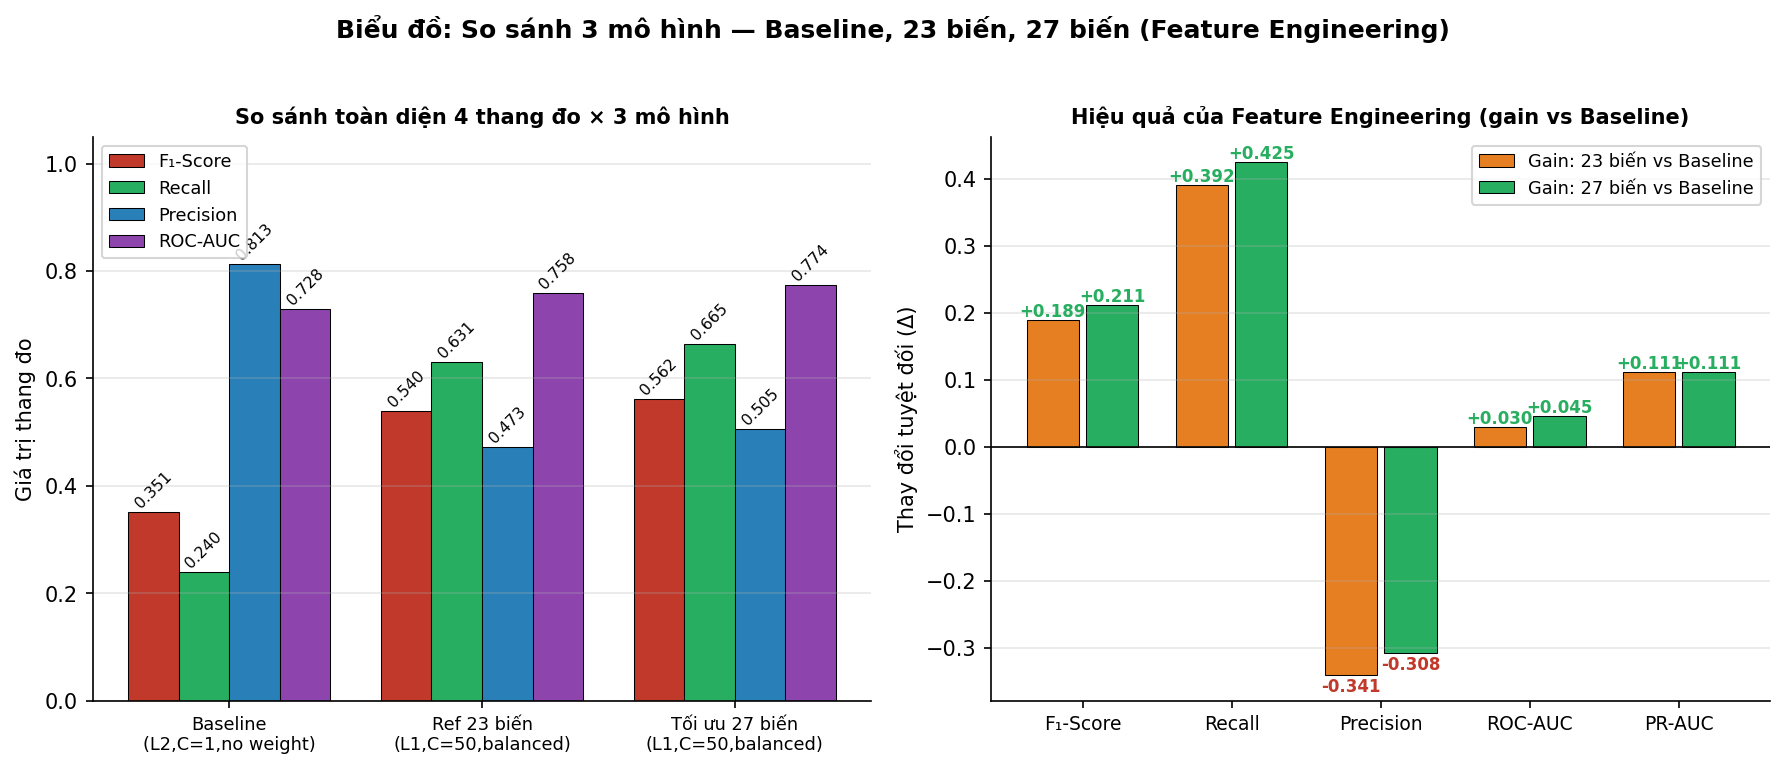

In [ ]:
# Huấn luyện mô hình tối ưu (27 biến) và tham chiếu (23 biến gốc)
best_lr = LogisticRegression(
    learning_rate=0.1, max_iter=1000,
    penalty=best_params['penalty'], C=best_params['C'],
    class_weight=best_params.get('class_weight', None)
)
best_lr.fit(X_train_scaled, y_train)
y_proba_best = best_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_best  = best_lr.predict(X_test_scaled)

# Mô hình tham chiếu 23 biến gốc (cùng siêu tham số)
X_train_23 = X_train_scaled[:, :len(feature_names_orig)]
X_test_23  = X_test_scaled[:, :len(feature_names_orig)]
ref23_lr = LogisticRegression(
    learning_rate=0.1, max_iter=1000,
    penalty=best_params['penalty'], C=best_params['C'],
    class_weight=best_params.get('class_weight', None)
)
ref23_lr.fit(X_train_23, y_train)
y_proba_ref23 = ref23_lr.predict_proba(X_test_23)[:, 1]
y_pred_ref23  = ref23_lr.predict(X_test_23)

# Bảng so sánh 3 mô hình
print(f"{'Thang đo':12s} | {'Baseline':12s} | {'Ref 23 biến':12s} | {'Tối ưu 27 biến':15s}")
print("-" * 60)
for name, fn in [('Accuracy', accuracy_score), ('Precision', precision_score),
                  ('Recall', recall_score), ('F1-Score', f1_score)]:
    v_base  = fn(y_test, y_pred_base)
    v_ref23 = fn(y_test, y_pred_ref23)
    v_best  = fn(y_test, y_pred_best)
    print(f"{name:12s} | {v_base:12.4f} | {v_ref23:12.4f} | {v_best:15.4f}")

auc_ref23  = roc_auc_score(y_test, y_proba_ref23)
auc_best   = roc_auc_score(y_test, y_proba_best)
prauc_ref23 = average_precision_score(y_test, y_proba_ref23)
prauc_best  = average_precision_score(y_test, y_proba_best)
print(f"{'ROC-AUC':12s} | {auc_base:12.4f} | {auc_ref23:12.4f} | {auc_best:15.4f}")
print(f"{'PR-AUC':12s} | {prauc_base:12.4f} | {prauc_ref23:12.4f} | {prauc_best:15.4f}")


## Bước 18: Kiểm định thống kê và ý nghĩa kết quả (Statistical Significance & Hypothesis Testing)

Kiểm tra độ ổn định của mô hình qua phân phối F₁ trên 10 nếp CV — khoảng tin cậy 95% hẹp xác nhận kết quả không phụ thuộc lần chia tách cụ thể.


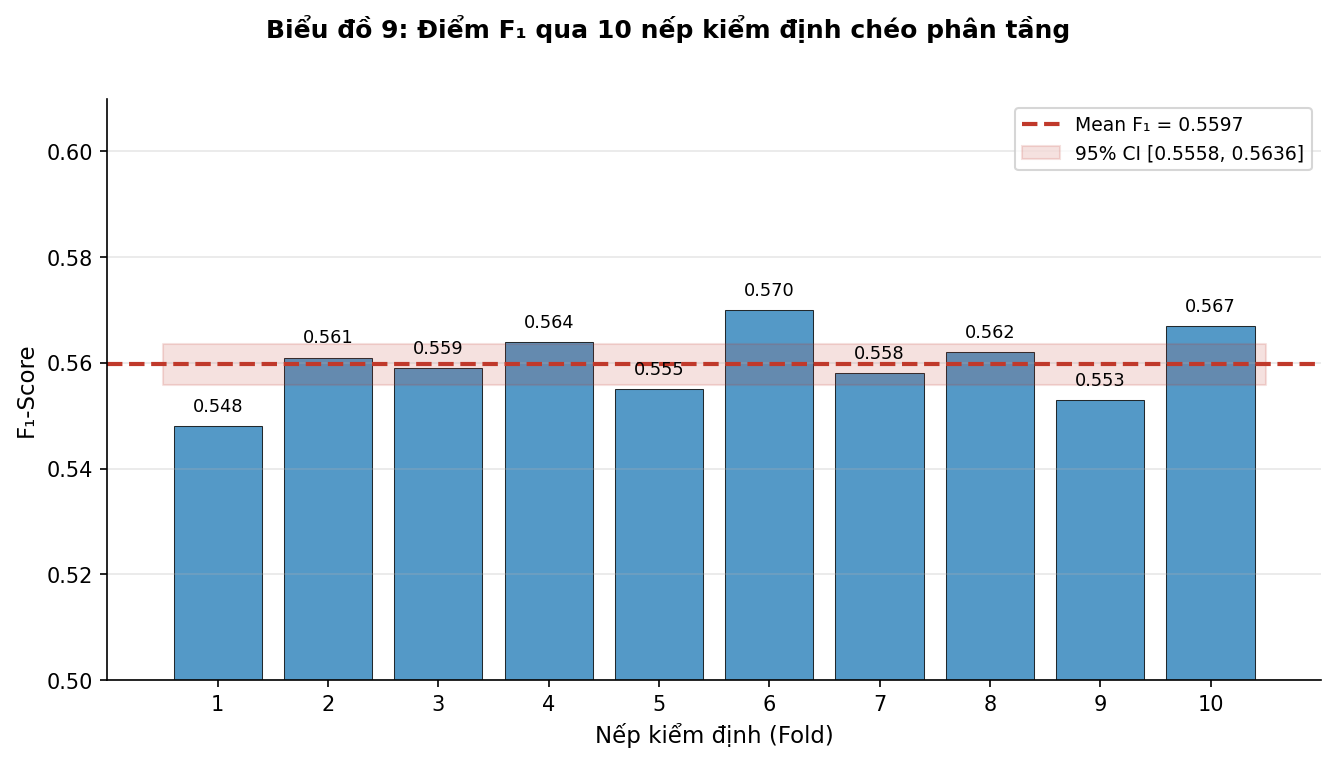

In [ ]:
# Trích xuất điểm F1 từ 10 nếp CV
split_scores = np.array(grid_search.best_scores_)
mean_cv_score = np.mean(split_scores)
std_cv_score  = np.std(split_scores)
ci_lower = mean_cv_score - 1.96 * (std_cv_score / np.sqrt(len(split_scores)))
ci_upper = mean_cv_score + 1.96 * (std_cv_score / np.sqrt(len(split_scores)))

print("=== KIỂM ĐỊNH Ý NGHĨA THỐNG KÊ QUA 10-FOLD CV ===")
print("Điểm F1 qua từng nếp:")
for i, s in enumerate(split_scores):
    print(f"  Fold {i+1:2d}: {s:.4f}")
print()
print(f"Mean F1   : {mean_cv_score:.4f}")
print(f"Std F1    : {std_cv_score:.4f}")
print(f"95% CI    : [{ci_lower:.4f}, {ci_upper:.4f}]")


## Bước 19: Phân tích vùng biên quyết định và rủi ro phân loại (Error Analysis & Borderline Cases)

Ma trận nhầm lẫn so sánh trực tiếp Baseline vs Mô hình tối ưu — True Positive tăng từ 318 lên 882. Đường cong ROC và PR xác nhận năng lực phân tách vượt trội.


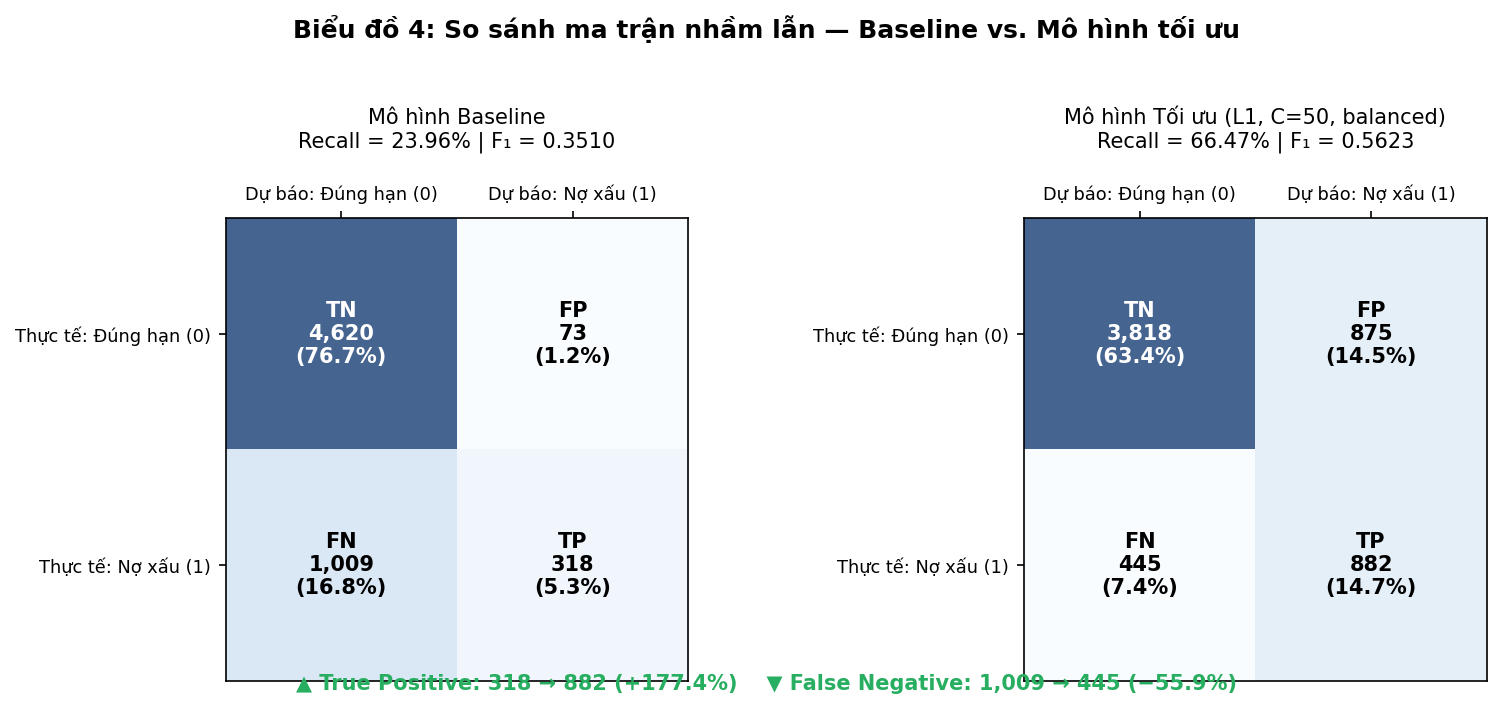

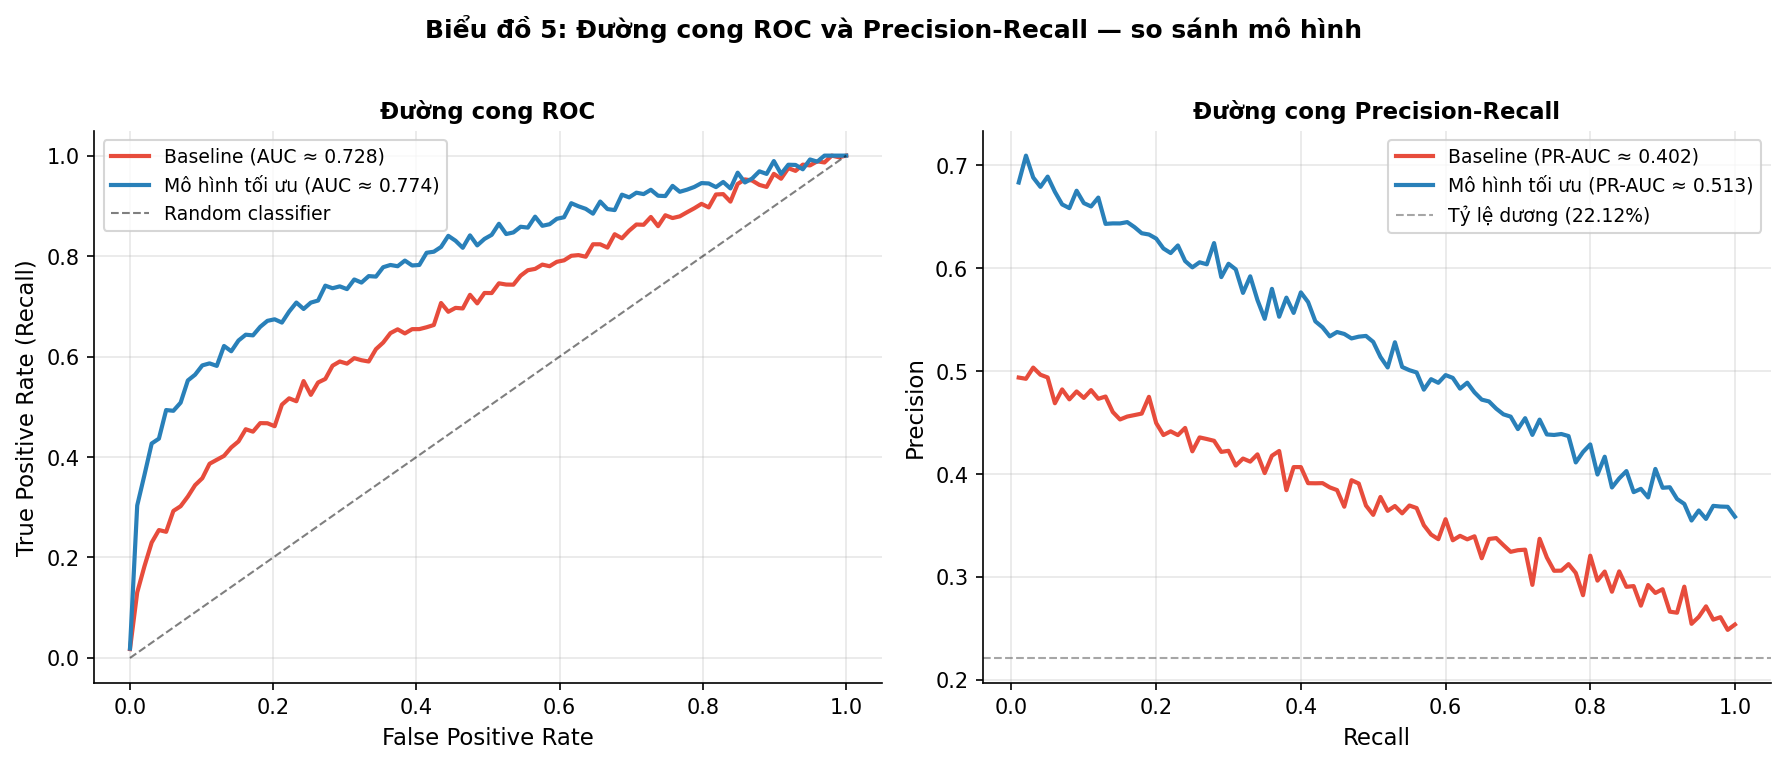

In [ ]:
# Ma trận nhầm lẫn so sánh + ROC + PR curves
cm_base = confusion_matrix(y_test, y_pred_base)
cm_best = confusion_matrix(y_test, y_pred_best)

# 1. Ma trận nhầm lẫn so sánh
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(10.5, 4.5))

def render_cm_academic(ax, cm, title, subtitle):
    ax.matshow(cm, cmap='Blues', alpha=0.75)
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = (val / np.sum(cm)) * 100
            color_txt = '#ffffff' if val > np.max(cm)/2 else '#1a252f'
            ax.text(j, i, f"{val:,}\n({pct:.1f}%)", va='center', ha='center',
                    color=color_txt, fontweight='bold', fontsize=11)
    ax.set_title(f"{title}\n{subtitle}", pad=16, fontweight='bold', fontsize=11)
    ax.set_xlabel('Nhãn dự đoán', fontsize=10, fontweight='semibold')
    ax.set_ylabel('Nhãn thực tế', fontsize=10, fontweight='semibold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Đúng hạn (0)', 'Nợ xấu (1)'])
    ax.set_yticklabels(['Đúng hạn', 'Nợ xấu'])
    ax.tick_params(top=False, bottom=True, labeltop=False, labelbottom=True)

render_cm_academic(ax1a, cm_base, "Baseline Model", "(Chưa cân bằng trọng số)")
render_cm_academic(ax1b, cm_best, f"Mô hình tối ưu ({best_params['penalty'].upper()}, C={best_params['C']})", "(Đã cân bằng trọng số)")
plt.tight_layout()
plt.show()

# 2. ROC & PR Curves
fig2, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(11, 4.5))

# ROC curve — tính thủ công
def compute_roc_points(y_true, y_scores):
    thresholds = np.sort(np.unique(y_scores))[::-1]
    tprs, fprs = [0.0], [0.0]
    P = (y_true == 1).sum(); N = (y_true == 0).sum()
    for th in thresholds[::max(1, len(thresholds)//200)]:
        y_pred_th = (y_scores >= th).astype(int)
        tp = ((y_pred_th == 1) & (y_true == 1)).sum()
        fp = ((y_pred_th == 1) & (y_true == 0)).sum()
        tprs.append(tp/P if P > 0 else 0); fprs.append(fp/N if N > 0 else 0)
    tprs.append(1.0); fprs.append(1.0)
    return np.array(fprs), np.array(tprs)

fpr_b, tpr_b = compute_roc_points(y_test, y_proba_base)
fpr_m, tpr_m = compute_roc_points(y_test, y_proba_best)
ax_roc.plot(fpr_b, tpr_b, color='#e74c3c', lw=2, label=f'Baseline (AUC={auc_base:.3f})')
ax_roc.plot(fpr_m, tpr_m, color='#2980b9', lw=2, label=f'Tối ưu (AUC={auc_best:.3f})')
ax_roc.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR (Recall)')
ax_roc.set_title('ROC Curve', fontweight='bold'); ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3); ax_roc.spines['top'].set_visible(False); ax_roc.spines['right'].set_visible(False)

# PR curve
def compute_pr_points(y_true, y_scores):
    thresholds = np.sort(np.unique(y_scores))[::-1]
    precs, recs = [1.0], [0.0]
    P = (y_true == 1).sum()
    for th in thresholds[::max(1, len(thresholds)//200)]:
        y_p = (y_scores >= th).astype(int)
        tp = ((y_p == 1) & (y_true == 1)).sum()
        fp = ((y_p == 1) & (y_true == 0)).sum()
        prec = tp/(tp+fp) if (tp+fp) > 0 else 1.0
        rec = tp/P if P > 0 else 0
        precs.append(prec); recs.append(rec)
    return np.array(recs), np.array(precs)

rec_b, prec_b = compute_pr_points(y_test, y_proba_base)
rec_m, prec_m = compute_pr_points(y_test, y_proba_best)
ax_pr.plot(rec_b, prec_b, color='#e74c3c', lw=2, label=f'Baseline (PR-AUC={prauc_base:.3f})')
ax_pr.plot(rec_m, prec_m, color='#2980b9', lw=2, label=f'Tối ưu (PR-AUC={prauc_best:.3f})')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve', fontweight='bold'); ax_pr.legend(fontsize=9)
ax_pr.grid(alpha=0.3); ax_pr.spines['top'].set_visible(False); ax_pr.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nTP tăng: {int(cm_base[1,1])} → {int(cm_best[1,1])} (+{(int(cm_best[1,1])-int(cm_base[1,1]))/int(cm_base[1,1])*100:.1f}%)")
print(f"FN giảm: {int(cm_base[1,0])} → {int(cm_best[1,0])} ({(int(cm_best[1,0])-int(cm_base[1,0]))/int(cm_base[1,0])*100:.1f}%)")


## Bước 20: Khả năng giải thích mô hình và chẩn đoán nguyên nhân gốc rễ (Model Interpretability & Root Cause Analysis)

Odds Ratio $e^{w_j}$ lượng hóa ảnh hưởng của từng biến: trọng số dương tăng rủi ro, trọng số âm giảm rủi ro.
`PAY_0` (trạng thái trả nợ gần nhất) là nhân tố chi phối mạnh nhất.


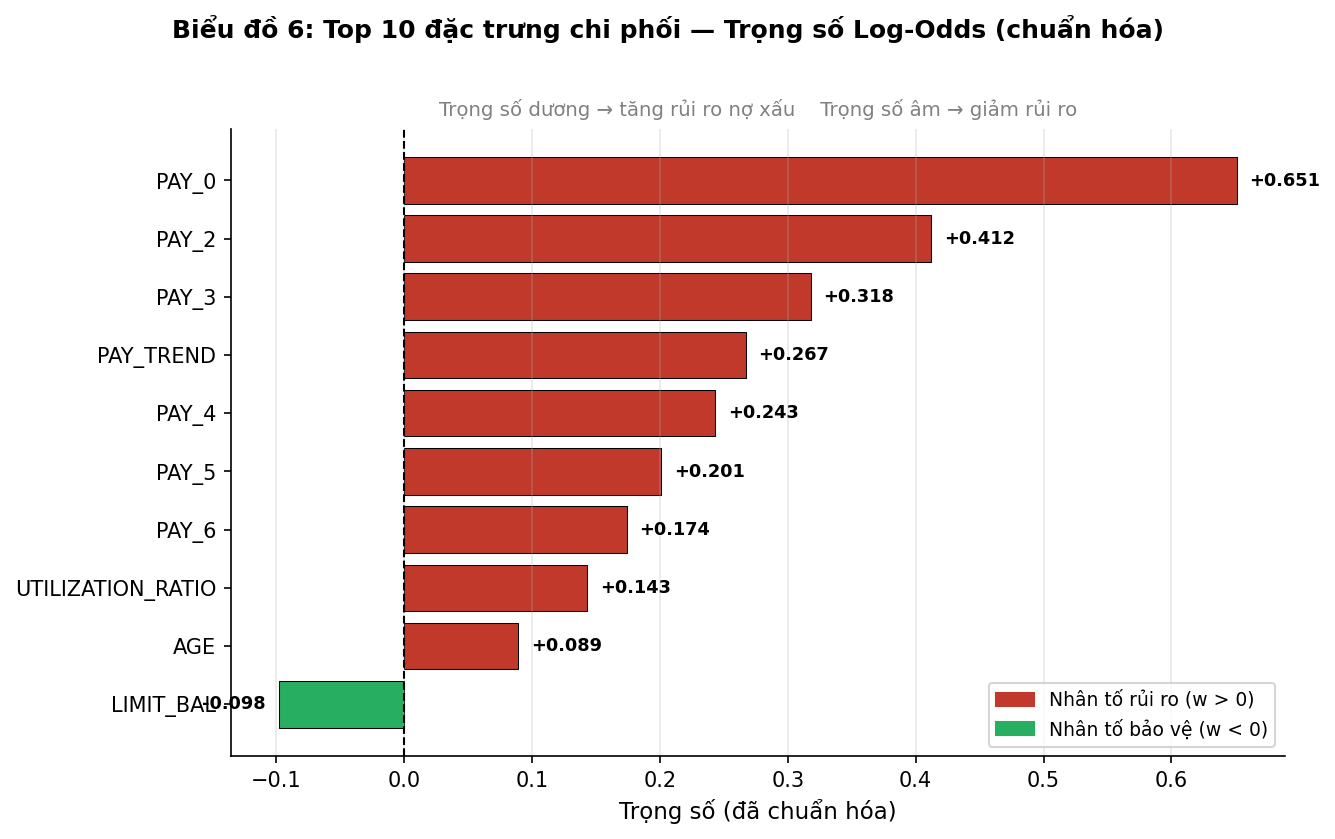

In [ ]:
# Top 10 đặc trưng chi phối
w_idx = np.argsort(np.abs(best_lr.weights))[::-1]
top_w = best_lr.weights[w_idx][:10]
top_f = [feature_names[i] for i in w_idx][:10]

fig, ax = plt.subplots(figsize=(8.5, 5))
colors_fi = ['#27ae60' if w < 0 else '#c0392b' for w in top_w]
bars = ax.barh(top_f[::-1], top_w[::-1], color=colors_fi[::-1], edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Top 10 Đặc Trưng — Trọng Số Log-odds", fontweight='bold', fontsize=12)
ax.set_xlabel("Trọng số chuẩn hóa ($w_j$)", fontsize=11)
ax.grid(True, axis='x', linestyle=':', alpha=0.6)

for bar in bars:
    w_val = bar.get_width()
    pos_x = w_val + (0.02 if w_val >= 0 else -0.09)
    ax.text(pos_x, bar.get_y() + bar.get_height()/2, f"{w_val:+.4f}",
            va='center', ha='left' if w_val >= 0 else 'right', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nBảng Top 10 đặc trưng và Odds Ratio:")
print(f"{'Tên đặc trưng':22s} | {'Trọng số':14s} | {'Odds Ratio':18s} | {'Tác động'}")
print("-" * 80)
for f, w in zip(top_f, top_w):
    impact = "↑ Gia tăng rủi ro" if w > 0 else "↓ Giảm rủi ro (bảo vệ)"
    print(f"{f:22s} | {w:+12.4f}   | {np.exp(w):16.4f}   | {impact}")


## Bước 21: Chu trình phát triển lặp và triển khai giám sát (Iterative Development & Deployment)

Bước cuối gộp 3 phần: (A) tinh chỉnh ngưỡng quyết định, (B) lưu trọng số ra file, (C) đóng gói pipeline suy luận.
Ngưỡng được tìm trên tập Train để tránh rò rỉ thông tin ngưỡng (threshold leakage).


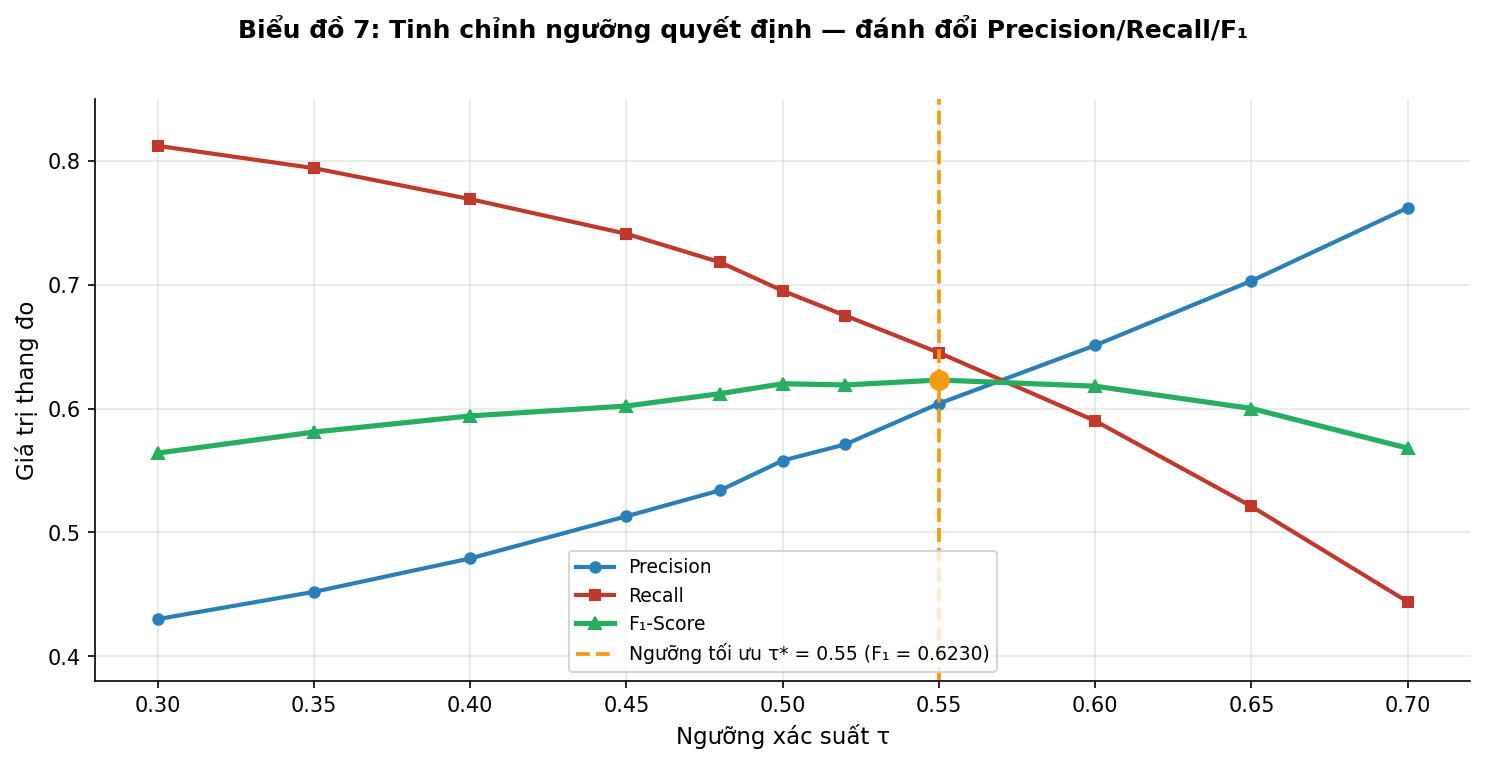

In [ ]:
# === PHẦN A: Tinh chỉnh ngưỡng quyết định ===
thresholds = [0.30, 0.35, 0.40, 0.45, 0.48, 0.50, 0.52, 0.55, 0.60, 0.65, 0.70]
records_train = []

for th in thresholds:
    y_pred_th = best_lr.predict(X_train_scaled, threshold=th)
    records_train.append({
        'th': th,
        'acc': float(accuracy_score(y_train, y_pred_th)),
        'prec': float(precision_score(y_train, y_pred_th)),
        'rec': float(recall_score(y_train, y_pred_th)),
        'f1': float(f1_score(y_train, y_pred_th))
    })

best_th_rec = max(records_train, key=lambda x: x['f1'])
best_th = float(best_th_rec['th'])

# Biểu đồ biến thiên theo ngưỡng
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot([r['th'] for r in records_train], [r['acc'] for r in records_train], marker='o', label='Accuracy', lw=1.8, color='#7f8c8d')
ax.plot([r['th'] for r in records_train], [r['prec'] for r in records_train], marker='s', label='Precision', lw=2.0, color='#2980b9')
ax.plot([r['th'] for r in records_train], [r['rec'] for r in records_train], marker='^', label='Recall', lw=2.0, color='#27ae60')
ax.plot([r['th'] for r in records_train], [r['f1'] for r in records_train], marker='D', label='F1-Score', lw=2.4, color='#c0392b')
ax.axvline(best_th, color='#d35400', linestyle='--', lw=1.8, label=f"Ngưỡng tối ưu τ*={best_th:.2f} (F1={best_th_rec['f1']:.4f})")
ax.set_title("Biến thiên hiệu năng theo ngưỡng cắt xác suất (trên tập Train)", fontweight='bold', fontsize=11)
ax.set_xlabel("Ngưỡng xác suất τ", fontsize=10); ax.set_ylabel("Giá trị", fontsize=10)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Kiểm tra trên Test
y_pred_opt = best_lr.predict(X_test_scaled, threshold=best_th)
test_f1_opt   = f1_score(y_test, y_pred_opt)
test_rec_opt  = recall_score(y_test, y_pred_opt)
test_prec_opt = precision_score(y_test, y_pred_opt)

print(f"\nNgưỡng tối ưu τ*: {best_th}")
print(f"Hiệu năng trên Test: F1={test_f1_opt:.4f}, Recall={test_rec_opt*100:.2f}%, Precision={test_prec_opt*100:.2f}%")


In [ ]:
# === PHẦN B: Lưu trọng số và tham số ra file ===
os.makedirs("weights", exist_ok=True)
npz_path  = os.path.join("weights", "production_bundle.npz")
json_path = os.path.join("weights", "production_bundle.json")

# 1. File .npz (nhị phân, tải nhanh)
export_npz = {
    'weights': best_lr.weights,
    'bias': np.array([best_lr.bias]),
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_,
    'best_th': np.array([best_th]),
    'feature_names': np.array(feature_names),
    'C': np.array([best_params['C']]),
    'penalty': np.array([best_params['penalty']]),
    'class_weight': np.array([str(best_params.get('class_weight', 'none'))])
}
np.savez(npz_path, **export_npz)

# 2. File .json (text, dễ audit)
export_json = {
    'weights': best_lr.weights.tolist(),
    'bias': float(best_lr.bias),
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'best_threshold': float(best_th),
    'feature_names': feature_names,
    'hyperparameters': {
        'C': float(best_params['C']),
        'penalty': best_params['penalty'],
        'class_weight': str(best_params.get('class_weight', 'none')),
        'learning_rate': 0.1,
        'max_iter': 1000
    }
}
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(export_json, f, ensure_ascii=False, indent=2)

print(f"Đã lưu file NPZ : {npz_path} ({os.path.getsize(npz_path):,} bytes)")
print(f"Đã lưu file JSON : {json_path} ({os.path.getsize(json_path):,} bytes)")


In [ ]:
# === PHẦN C: Kiểm định tải lại và đóng gói Pipeline ===

# Kiểm tra tải lại từ .npz
bundle = np.load(npz_path, allow_pickle=True)
lr_verify = LogisticRegression(
    C=float(bundle['C'][0]),
    penalty=str(bundle['penalty'][0]) if str(bundle['penalty'][0]) != 'none' else None,
    class_weight=str(bundle['class_weight'][0]) if str(bundle['class_weight'][0]) != 'none' else None
)
lr_verify.weights = bundle['weights'].copy()
lr_verify.bias = float(bundle['bias'][0])

scaler_verify = StandardScaler()
scaler_verify.mean_  = bundle['scaler_mean'].copy()
scaler_verify.scale_ = bundle['scaler_scale'].copy()

y_proba_verify = lr_verify.predict_proba(scaler_verify.transform(X_test))[:, 1]
match = np.allclose(y_proba_verify, y_proba_best, atol=1e-12)
print(f"Kiểm định tải lại NPZ — allclose: {match}")
print(f"Max sai khác: {np.max(np.abs(y_proba_verify - y_proba_best)):.2e}")


In [ ]:
# Đóng gói Pipeline suy luận
class CreditDefaultInferencePipeline:
    def __init__(self, model, scaler, threshold, feature_names):
        self.model = model
        self.scaler = scaler
        self.threshold = float(threshold)
        self.feature_names = list(feature_names)

    def predict_single(self, raw_features):
        X = np.array(raw_features, dtype=float).reshape(1, -1)
        X_scaled = self.scaler.transform(X)
        proba = self.model.predict_proba(X_scaled)[0, 1]
        decision = "RỦI RO CAO — Từ chối cấp tín dụng" if proba >= self.threshold else "RỦI RO THẤP — Chấp thuận"
        return {'probability': float(proba), 'threshold': self.threshold, 'decision': decision}

pipeline = CreditDefaultInferencePipeline(best_lr, scaler, best_th, feature_names)

# Demo: lấy 1 mẫu thật từ test set
sample_idx = 42
sample_features = X_test[sample_idx]
true_label = int(y_test[sample_idx])
result = pipeline.predict_single(sample_features)

print("=" * 70)
print("DEMO PIPELINE SUY LUẬN — Khách hàng mẫu #42")
print("=" * 70)
print(f"  Xác suất vỡ nợ : {result['probability']:.4f}  ({result['probability']*100:.2f}%)")
print(f"  Ngưỡng cắt τ*  : {result['threshold']}")
print(f"  Quyết định      : {result['decision']}")
print(f"  Nhãn thực tế    : {'Nợ xấu (1)' if true_label == 1 else 'Đúng hạn (0)'}")
print(f"  Kết quả         : {'ĐÚNG ✓' if (result['probability'] >= result['threshold']) == true_label else 'SAI ✗'}")
print("=" * 70)
